# 03 · Estimators & trust

Notebook 02 showed *that* naive A/B is biased and *that* budget-split recovers truth. This notebook
is the toolkit and the guardrails:

1. **The estimator zoo** — naive vs budget-split as a forest plot against the true ATE.
2. **Standard errors & the A/A nulls** — why a *cluster-randomized* A/A needs cluster-robust SEs
   (the Glovo lesson), and the SRM trust gate.
3. **The ramp-selection confound** — why we analyze at *fixed allocation*, shown by making a
   **no-op** treatment look "significant" purely through survival selection.

Everything uses `compute_tau=False` on the analysis runs (truth comes from shadow runs).

In [1]:
import nbtools; nbtools.use_repo_root(); nbtools.set_style()
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from engine.market import run
from engine.oracle import global_ate
from inference import naive, cluster, budget_split
from inference.base import user_outcomes
from nbtools import BLUE, GREEN, PINK, ORANGE, GRAY, forest

EXP = "exp_reward_sizing"

## 1. The estimator zoo — a forest plot

In the single-advertiser world (budget is the only interference channel), at 50% allocation: the
**naive** difference-in-means misses the true ATE; the **budget-split** design lands on it. A forest
plot makes "covers truth / doesn't" visual.

true ATE = -0.0408
naive          -0.03046  [-0.04344, -0.01748]  se=0.00662  n=(4667,4633)
budget_split   -0.03846  [-0.05124, -0.02569]  se=0.00652  n=(4667,4633)


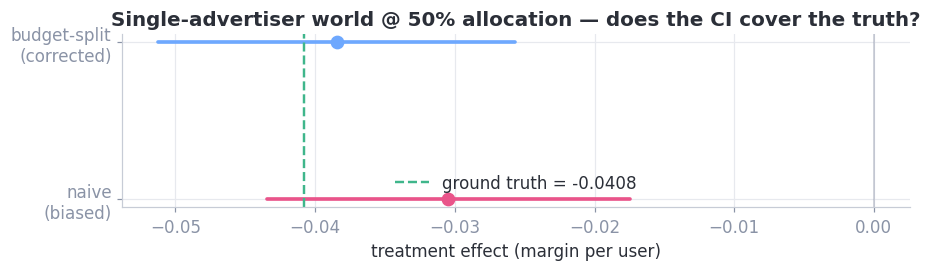

In [2]:
icfg = nbtools.iso_cfg(seed=3, users=8000, days=14)
igt = global_ate(icfg, EXP)

run(nbtools.fixed_alloc(icfg, 0.5, "standard"), output_dir="i_std", compute_tau=False)
eff_naive = naive.estimate(user_outcomes("i_std", EXP))
run(nbtools.fixed_alloc(icfg, 0.5, "budget_split"), output_dir="i_bs", compute_tau=False)
eff_bs = budget_split.estimate(user_outcomes("i_bs", EXP))

print(f"true ATE = {igt.ate:+.4f}")
print(eff_naive)
print(eff_bs)

fig, ax = plt.subplots(figsize=(8.5, 2.6))
forest(ax, [eff_bs, eff_naive], ["budget-split\n(corrected)", "naive\n(biased)"],
       truth=igt.ate, colors=[BLUE, PINK])
ax.set_title("Single-advertiser world @ 50% allocation — does the CI cover the truth?")
plt.tight_layout(); plt.show()

## 2. Standard errors & the A/A nulls (false-positive control)

An **A/A** test has *no* real effect — the arms are identical. A trustworthy estimator must **not**
flag one. We run a small multi-advertiser world that carries both A/A nulls (`aa_null_1`
user-randomized, `aa_null_2` cluster-randomized) and check that neither flags.

We also keep the **cluster-robust** estimator in the toolkit (the Glovo lesson: when you randomize at
the cluster level but analyze at the user level, intra-cluster correlation makes the naive SE too
small → false positives). **Honest caveat, visible below:** in the *current* engine, `cluster_id` is
a random label with **no shared structure**, so the intra-cluster correlation (ICC) ≈ 0 and the
cluster-robust SE ≈ the naive SE — there's nothing to inflate *yet*. The correction becomes
necessary once we model **cluster-level interference** (shared attention/preference/budget — the
ranking/attention leg, Phase 2). The estimator is ready; the engine needs the structure to make it
bite. (Tracked in `pm/BACKLOG.md`.)

In [3]:
wcfg = nbtools.world_cfg(seed=7, users=4000, days=26, budget_mu=6.0)  # ramp completes by day 25
wsum = run(wcfg, output_dir="world", compute_tau=False)

# aa_null_2 is cluster-randomized — compare the naive (user-level) SE to the cluster-robust SE
naive_aa2 = naive.estimate_from_log("world", "aa_null_2")
clust_aa2 = cluster.estimate_from_log("world", "aa_null_2")
print("aa_null_2 (cluster-randomized):")
print(" ", naive_aa2)
print(" ", clust_aa2)
ratio = clust_aa2.se / naive_aa2.se
print(f"  cluster-robust SE is {ratio:.2f}× the naive SE — "
      + ("≈1, i.e. ICC≈0: clusters are inert labels in the current engine (see caveat above)."
         if ratio < 1.1 else "the cluster-robust SE is meaningfully larger (ICC>0)."))

aa_null_2 (cluster-randomized):
  naive          +0.00777  [-0.11825, +0.13378]  se=0.06428  n=(3545,2955)
  cluster        +0.00777  [-0.12274, +0.13827]  se=0.06658  n=(3545,2955)
  cluster-robust SE is 1.04× the naive SE — ≈1, i.e. ICC≈0: clusters are inert labels in the current engine (see caveat above).


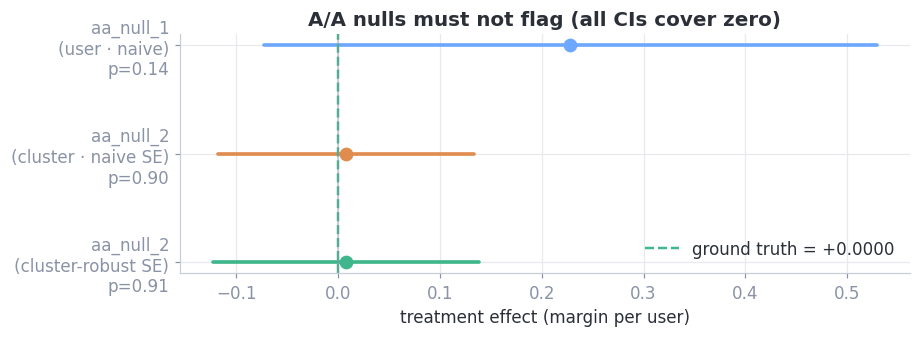


SRM trust gate (EVENT_LOG §6.6):
  aa_null_1  unit=user    realized=0.501 intended=0.500  ok=True
  aa_null_2  unit=cluster realized=0.550 intended=0.500  ok=True


In [4]:
# Both A/A nulls should be non-significant; show the effect ± CI with zero marked.
effs, labels, cols = [], [], []
for exp_id, est, lab, c in [
    ("aa_null_1", naive, "aa_null_1\n(user · naive)", BLUE),
    ("aa_null_2", naive, "aa_null_2\n(cluster · naive SE)", ORANGE),
    ("aa_null_2", cluster, "aa_null_2\n(cluster-robust SE)", GREEN),
]:
    e = est.estimate_from_log("world", exp_id)
    effs.append(e); labels.append(f"{lab}\np={e.p_value:.2f}"); cols.append(c)

fig, ax = plt.subplots(figsize=(8.5, 3.2))
forest(ax, effs, labels, truth=0.0, colors=cols)
ax.set_title("A/A nulls must not flag (all CIs cover zero)")
plt.tight_layout(); plt.show()

# the SRM trust gate (cluster-unit-aware)
print("\nSRM trust gate (EVENT_LOG §6.6):")
for exp_id in ("aa_null_1", "aa_null_2"):
    r = wsum["srm"][exp_id]
    print(f"  {exp_id:<10} unit={r['unit']:<7} realized={r['realized_share']:.3f} "
          f"intended={r['intended_share']:.3f}  ok={r['ok']}")

Both A/A nulls correctly fail to flag (false-positive control ✓). The cluster-robust SE matches the
naive SE here because clusters carry no shared structure yet — the honest "the tool is ready, the
engine needs cluster-level interference to make it necessary" point from above.

## 3. The ramp-selection confound — why we analyze at *fixed* allocation

**Ramp-selection**, defined: a *ramp* raises the treatment allocation over time (1% → 5% → 20% → …),
the standard way to de-risk a launch. But with our monotone hash assignment a user only flips to
"treatment" once the allocation climbs past their fixed threshold. Combined with **churn**, that
means early-leaving users are stuck in control, so the "treatment" group **over-represents
long-survivors** — who convert more for reasons that have nothing to do with the treatment. That is
*selection bias*, not a treatment effect.

**Arm balance** = how the assigned users split across arms. Clean randomization at a fixed allocation
gives the designed split (≈50/50 at 50%); a ramp leaves treatment **under-filled** and confounded.

We expose this with `exp_offer_ranking`, whose lever is a **no-op** (a ranker swap with no utility
effect), so its true effect is **exactly zero** — any "effect" the naive estimator reports is pure
artefact.

In [5]:
# truth: the ranking lever does nothing -> global ATE ~ 0
rank_gt = global_ate(wcfg, "exp_offer_ranking")
print(f"TRUE effect of the (no-op) ranking lever: ATE = {rank_gt.ate:+.4f}  (≈ 0, as it should be)\n")

# ramped analysis (the confounded one)
df_ramp = user_outcomes("world", "exp_offer_ranking")
eff_ramp = naive.estimate(df_ramp)
counts_ramp = df_ramp.arm.value_counts()
nconv_ramp = df_ramp.groupby("arm").n_conv.mean()

# fixed-allocation analysis (the clean one): constant 50% from day 0
run(nbtools.fixed_alloc(wcfg, 0.5), output_dir="world_fixed", compute_tau=False)
df_fix = user_outcomes("world_fixed", "exp_offer_ranking")
eff_fix = naive.estimate(df_fix)
counts_fix = df_fix.arm.value_counts()

print("RAMPED   naive effect on no-op lever: "
      f"{eff_ramp.point:+.4f}  (p={eff_ramp.p_value:.1e})  <- spurious!")
print(f"  arm balance: treatment={counts_ramp.get('treatment',0)}, control={counts_ramp.get('control',0)}")
print(f"  mean conversions/user: treatment={nconv_ramp.get('treatment',0):.2f}, "
      f"control={nconv_ramp.get('control',0):.2f}  <- 'treatment' survivors convert more")
print("\nFIXED-ALLOC naive effect on no-op lever: "
      f"{eff_fix.point:+.4f}  (p={eff_fix.p_value:.2f})  <- ~0, no flag")
print(f"  arm balance: treatment={counts_fix.get('treatment',0)}, control={counts_fix.get('control',0)}")

TRUE effect of the (no-op) ranking lever: ATE = +0.0000  (≈ 0, as it should be)



RAMPED   naive effect on no-op lever: +0.3408  (p=7.7e-10)  <- spurious!
  arm balance: treatment=2033, control=4467
  mean conversions/user: treatment=1.37, control=0.93  <- 'treatment' survivors convert more

FIXED-ALLOC naive effect on no-op lever: -0.0092  (p=0.85)  <- ~0, no flag
  arm balance: treatment=3244, control=3256


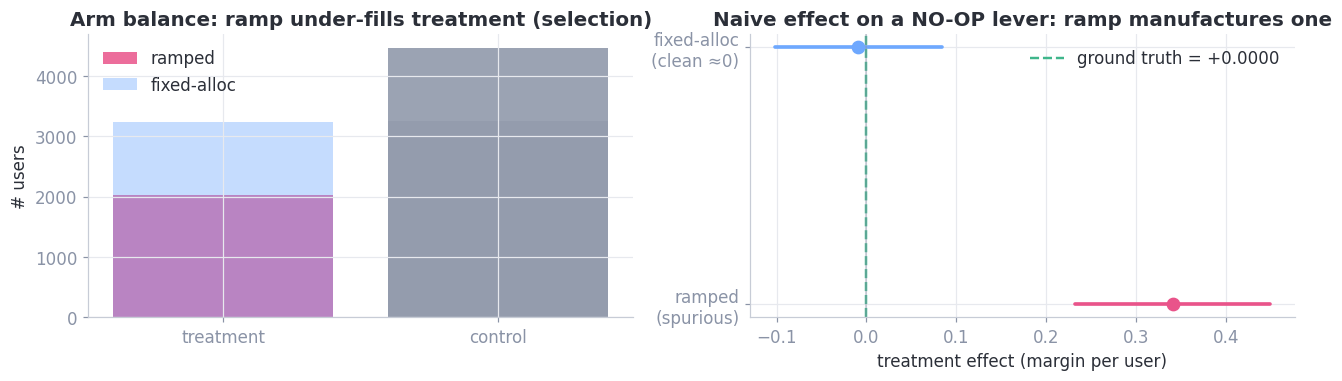

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
# left: arm balance
ax[0].bar(["treatment", "control"],
          [counts_ramp.get("treatment", 0), counts_ramp.get("control", 0)],
          color=[PINK, GRAY], alpha=0.85, label="ramped")
ax[0].bar(["treatment", "control"],
          [counts_fix.get("treatment", 0), counts_fix.get("control", 0)],
          color=[BLUE, GRAY], alpha=0.4, label="fixed-alloc")
ax[0].set_title("Arm balance: ramp under-fills treatment (selection)")
ax[0].set_ylabel("# users"); ax[0].legend()
# right: the spurious effect vs truth
forest(ax[1], [eff_fix, eff_ramp], ["fixed-alloc\n(clean ≈0)", "ramped\n(spurious)"],
       truth=rank_gt.ate, colors=[BLUE, PINK])
ax[1].set_title("Naive effect on a NO-OP lever: ramp manufactures one")
plt.tight_layout(); plt.show()

The no-op lever's true effect is zero. Under the ramp the naive estimate is large and "significant"
— pure survival selection, not a treatment effect. At fixed allocation the arms are balanced and the
estimate is ~0, as it must be. **This is why the money shot (notebook 02) and every recovery test
run at fixed allocation**, and why `cli infer` flags ramped rows. The ramped run is still the
realistic substrate for the dashboard — it's the *analysis* that must hold allocation fixed.

---
**Recap.** A forest plot of corrected-vs-naive; the cluster-robust SE fix for cluster-randomized
A/A; the SRM trust gate; and a no-op lever made "significant" by the ramp — the confound that
pins our analysis to fixed allocation. The claims here live in `tests/test_aa_null.py` and
`tests/test_recovery.py`.

In [7]:
import shutil
for d in ("i_std", "i_bs", "world", "world_fixed"):
    shutil.rmtree(d, ignore_errors=True)